In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load all CSV files
dataframes = []
for m in range(1, 13):
    df = pd.read_csv(f"D:/Guvi/Projects/mini/Analyzing_Personal_Expenses/data_simulation/expenses_{m:02}.csv")
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

# Convert date
data['date'] = pd.to_datetime(data['date'])

In [5]:
# Display basic info
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2400 non-null   datetime64[ns]
 1   category      2400 non-null   object        
 2   payment_mode  2400 non-null   object        
 3   description   2400 non-null   object        
 4   amount_paid   2400 non-null   float64       
 5   cashback      2400 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 112.6+ KB


,date,amount_paid,cashback
count,2400,2400.000000,2400.00000
mean,2024-06-29 00:39:00,2531.638962,17.95000
min,2024-01-01 00:00:00,52.040000,0.00000
25%,2024-03-30 18:00:00,1300.165000,0.00000
50%,2024-06-29 00:00:00,2543.595000,0.00000
75%,2024-09-28 00:00:00,3749.892500,0.00000
max,2024-12-27 00:00:00,4996.820000,199.97000
std,NaN,1424.993523,45.77826


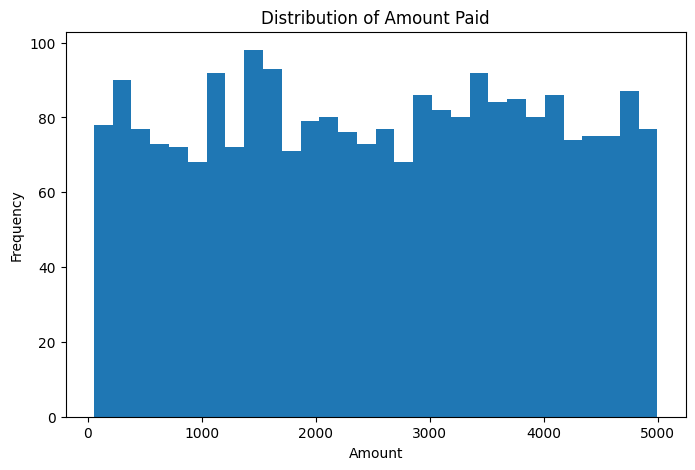

In [6]:
# Distribution Plot
plt.figure(figsize=(8,5))
plt.hist(data['amount_paid'], bins=30)
plt.title("Distribution of Amount Paid")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [7]:
# 1. Total amount spent in each category
print("Total Spending by Category:", data.groupby('category')['amount_paid'].sum())

Total Spending by Category: category
Bills            868339.13
Entertainment    843846.33
Food             831399.15
Gifts            885265.68
Shopping         891189.97
Transport        918079.05
Travel           837814.20
Name: amount_paid, dtype: float64


In [8]:
# 2. Total amount spent using each payment mode
print("Total Spending by Payment Mode:", data.groupby('payment_mode')['amount_paid'].sum())

Total Spending by Payment Mode: payment_mode
Cash           1290229.18
Credit Card    1223482.85
Debit Card     1298143.12
Net Banking    1129171.27
UPI            1134907.09
Name: amount_paid, dtype: float64


In [9]:
# 3. Total cashback received
print("Total Cashback Received:", data['cashback'].sum())

Total Cashback Received: 43080.0


In [10]:
# 4. Top 5 most expensive categories
print("Top 5 Categories by Spending:", data.groupby('category')['amount_paid'].sum().sort_values(ascending=False).head())

Top 5 Categories by Spending: category
Transport        918079.05
Shopping         891189.97
Gifts            885265.68
Bills            868339.13
Entertainment    843846.33
Name: amount_paid, dtype: float64


In [11]:
# 5. Spending on transportation via payment modes
if 'Transport' in data['category'].unique():
    print("Transport Spending by Payment Mode:", data[data['category']=='Transport'].groupby('payment_mode')['amount_paid'].sum())

Transport Spending by Payment Mode: payment_mode
Cash           199847.69
Credit Card    148556.75
Debit Card     195482.11
Net Banking    195318.83
UPI            178873.67
Name: amount_paid, dtype: float64


In [12]:
# 6. Transactions with cashback
cashback_txn = data[data['cashback'] > 0]
print("Transactions with Cashback:", len(cashback_txn))

Transactions with Cashback: 442


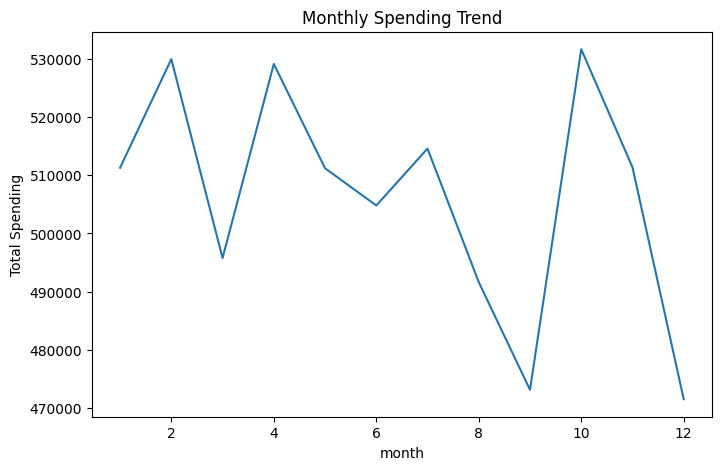

Monthly Total Spending: month
1     511268.93
2     529911.45
3     495791.75
4     529075.26
5     511187.02
6     504799.47
7     514556.94
8     491648.74
9     473171.66
10    531607.86
11    511355.44
12    471558.99
Name: amount_paid, dtype: float64


In [14]:
# 7. Total spending per month
# Monthly Trend
data['month'] = data['date'].dt.month
monthly_trend = data.groupby('month')['amount_paid'].sum()
monthly_trend.plot(kind='line', figsize=(8,5), title='Monthly Spending Trend')
plt.ylabel('Total Spending')
plt.show()
print("Monthly Total Spending:", monthly_trend)

In [15]:
# 8. Highest spending in Travel, Entertainment, Gifts
subset_cats = ['Travel','Entertainment','Gifts']
print("Spending in High-Interest Categories:", data[data['category'].isin(subset_cats)].groupby(['month','category'])['amount_paid'].sum())

Spending in High-Interest Categories: month  category     
1      Entertainment    45282.77
       Gifts            68404.55
       Travel           73733.27
2      Entertainment    89674.26
       Gifts            58365.00
       Travel           62914.88
3      Entertainment    83091.26
       Gifts            77174.53
       Travel           60316.13
4      Entertainment    77821.65
       Gifts            75997.12
       Travel           87267.17
5      Entertainment    65280.89
       Gifts            71322.94
       Travel           81471.67
6      Entertainment    78549.14
       Gifts            90366.61
       Travel           94699.67
7      Entertainment    76817.64
       Gifts            76727.58
       Travel           62472.14
8      Entertainment    73960.92
       Gifts            72137.99
       Travel           60270.78
9      Entertainment    70797.14
       Gifts            49121.77
       Travel           68527.57
10     Entertainment    49991.88
       Gifts     

In [16]:
# 9. Recurring expenses: simulated check
print("Recurring Categories Count:", data.groupby('category')['description'].count().sort_values(ascending=False))

Recurring Categories Count: category
Transport        370
Gifts            350
Shopping         350
Bills            339
Travel           338
Entertainment    334
Food             319
Name: description, dtype: int64


In [17]:
# 10. Cashback earned per month
print("Cashback Earned Monthly:", data.groupby('month')['cashback'].sum())

Cashback Earned Monthly: month
1     2605.39
2     4377.16
3     3463.91
4     2996.61
5     2322.93
6     4130.55
7     3869.91
8     3824.45
9     4011.58
10    4186.91
11    4216.45
12    3074.15
Name: cashback, dtype: float64


In [18]:
# 12. Travel cost analysis
print("Travel Costs:", data[data['category']=='Travel']['amount_paid'].describe())

Travel Costs: count     338.000000
mean     2478.740237
std      1495.276373
min        52.040000
25%      1180.640000
50%      2405.905000
75%      3827.185000
max      4984.570000
Name: amount_paid, dtype: float64


In [19]:
# 13. Grocery weekday vs weekend analysis
if 'Groceries' in data['category'].unique():
    data['weekday'] = data['date'].dt.weekday
    print("Grocery Spending Weekend vs Weekday:", data[data['category']=='Groceries'].groupby(data['weekday']>=5)['amount_paid'].sum())

In [20]:
# 14. Priority categories based on average spending
avg_spending = data['amount_paid'].mean()
priority = data.groupby('category')['amount_paid'].sum().apply(lambda x: 'High Priority' if x>avg_spending else 'Low Priority')
print("Category Priority Classification:", priority)

Category Priority Classification: category
Bills            High Priority
Entertainment    High Priority
Food             High Priority
Gifts            High Priority
Shopping         High Priority
Transport        High Priority
Travel           High Priority
Name: amount_paid, dtype: object


In [21]:
# 15. Category contributing highest percent of total
percent = (data.groupby('category')['amount_paid'].sum() / data['amount_paid'].sum())*100
print("Category Contribution Percentages:", percent.sort_values(ascending=False).head(1))

Category Contribution Percentages: category
Transport    15.11009
Name: amount_paid, dtype: float64


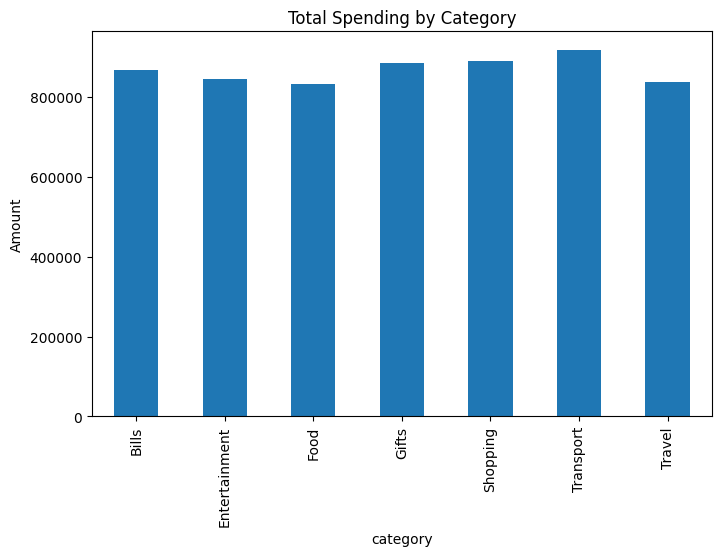

In [22]:
# Category Spending
category_spending = data.groupby('category')['amount_paid'].sum()
category_spending.plot(kind='bar', figsize=(8,5), title='Total Spending by Category')
plt.ylabel('Amount')
plt.show()

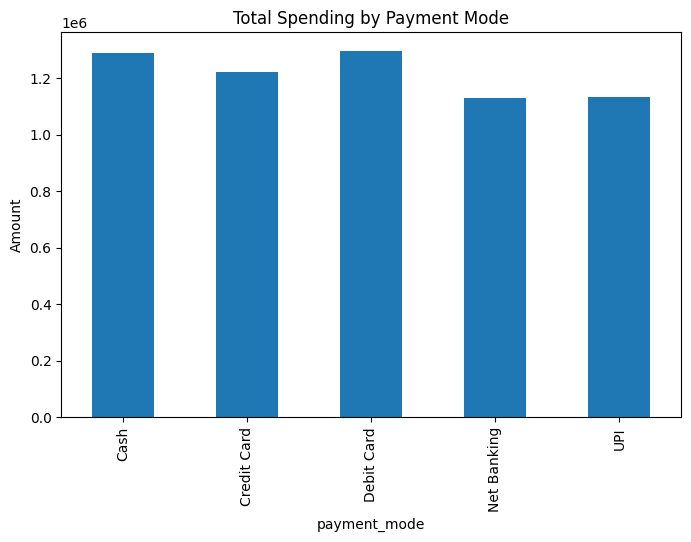

In [23]:
# Payment Mode Spending
payment_spending = data.groupby('payment_mode')['amount_paid'].sum()
payment_spending.plot(kind='bar', figsize=(8,5), title='Total Spending by Payment Mode')
plt.ylabel('Amount')
plt.show()